# 1. Introduction



## Intelligent Property Price Prediction

> Add blockquote

---







Real estate valuation plays a crucial role in property investment, urban planning, and financial decision-making. Traditionally, property prices are estimated through manual comparisons and expert assessments. However, with the increasing availability of housing datasets, machine learning techniques can be used to analyze property characteristics and predict market prices more accurately.

This project develops a machine learning-based system to predict property prices using housing data from Bengaluru. The system analyzes important property attributes such as location, total square footage, number of bedrooms, bathrooms, and other amenities.

The workflow of the project includes:

- Data exploration and visualization
- Data cleaning and preprocessing
- Feature engineering
- Outlier detection
- Machine learning model training
- Model evaluation

Two regression algorithms are implemented:

- Linear Regression
- Random Forest Regressor

The goal is to build a predictive model that estimates property prices and provides insights into the key factors influencing real estate values.


#2. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


#3. Load Dataset


In [ ]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


#4. Dataset Overview

In [ ]:
df.shape


(13320, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


#5. Exploratory Data Analysis


##Price Distribution


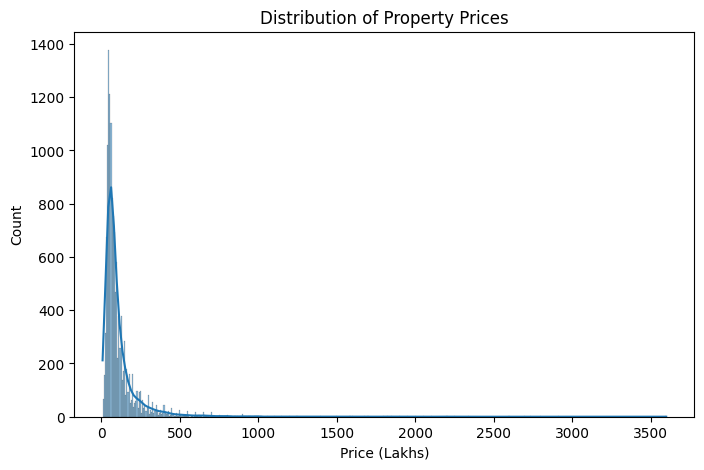

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=500, kde=True)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")

plt.show()

##Area vs Price

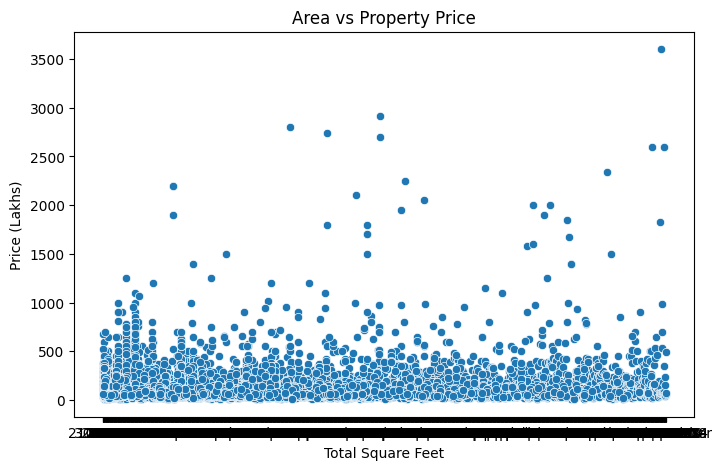

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='total_sqft', y='price', data=df)

plt.title("Area vs Property Price")
plt.xlabel("Total Square Feet")
plt.ylabel("Price (Lakhs)")

plt.show()

##BHK vs Price


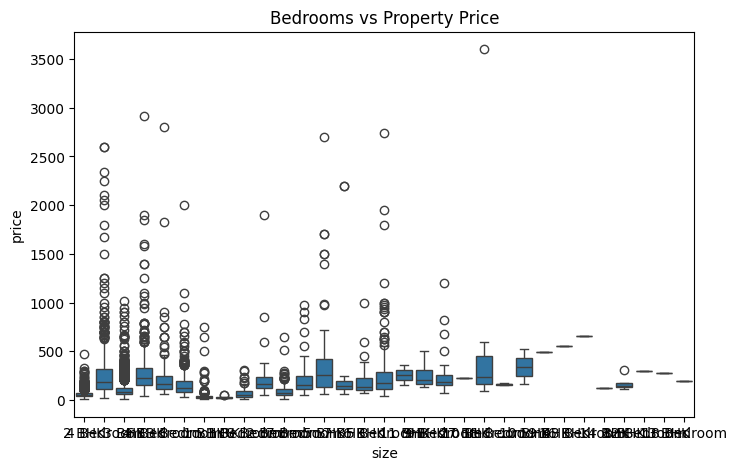

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='size', y='price', data=df)

plt.title("Bedrooms vs Property Price")

plt.show()

##Bathrooms vs Price


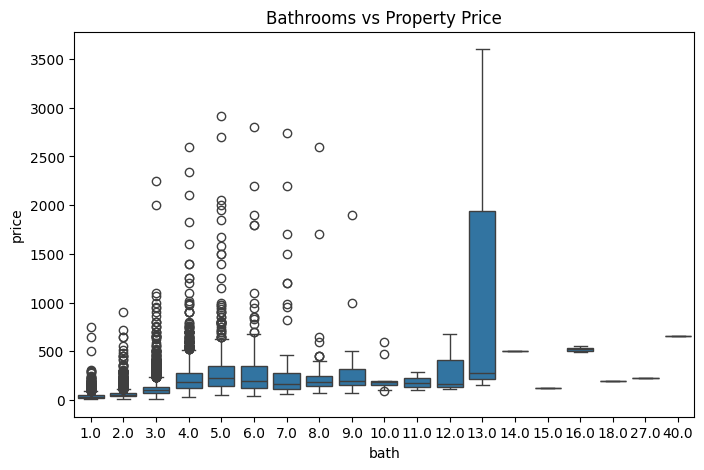

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bath', y='price', data=df)

plt.title("Bathrooms vs Property Price")

plt.show()


##Top Locations By Listing


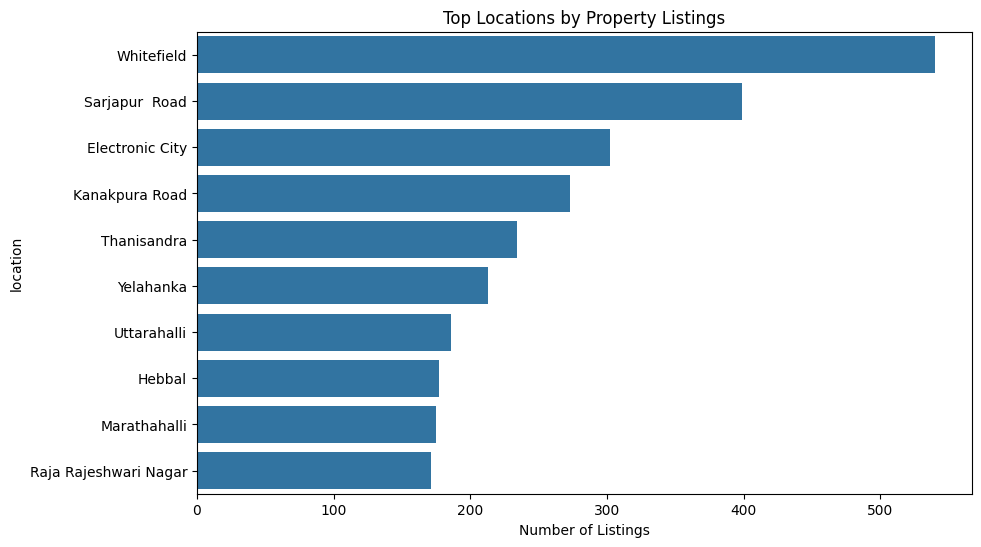

In [ ]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top Locations by Property Listings")
plt.xlabel("Number of Listings")

plt.show()


#6. Data Cleaning


Remove columns with excessive missing values.

In [ ]:
df = df.drop(['society','availability'], axis=1)

Remove rows with missing values.

In [ ]:
df = df.dropna()

#7. Feature Engineering

Extract BHK from size column.

In [ ]:
extracted_bhk_str = df['size'].str.split().str[0]
df['bhk'] = pd.to_numeric(extracted_bhk_str, errors='coerce')
df.dropna(subset=['bhk'], inplace=True)
df['bhk'] = df['bhk'].astype(int)

Remove original column.

In [ ]:
df = df.drop('size', axis=1)

#8. Convert Square Feet Values
Some values appear as ranges like 1200-1400.


In [ ]:
def convert_sqft(x):

    try:
        if '-' in str(x):
            a,b = x.split('-')
            return (float(a)+float(b))/2
        return float(x)

    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

Remove invalid rows.

In [ ]:
df = df.dropna()

#9. Price per Square Foot Analysis
Creating new feature

In [ ]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

Distribution

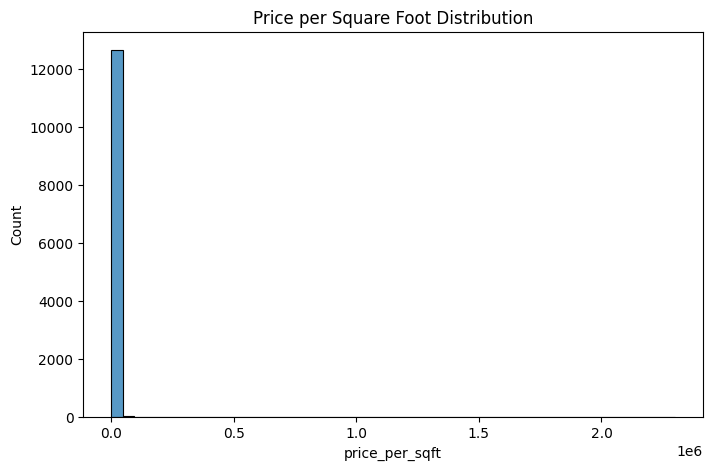

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['price_per_sqft'], bins=50)

plt.title("Price per Square Foot Distribution")

plt.show()

##Most Expensive Locations

In [ ]:
location_price = df.groupby('location')['price_per_sqft'].mean().sort_values(ascending=False)

location_price.head(10)

,price_per_sqft
location,
Grihalakshmi Layout,625000.000000
Srirampuram,481004.144004
Suragajakkanahalli,339363.636364
Weavers Colony,68801.313629
Raghuvanahalli,38647.926429
Sector 3 HSR Layout,31666.666667
Hsr layout sector3,31250.000000
J P Nagar 7th Phase Ramayya City,29166.666667
Kathreguppe,29166.666667


Visualization

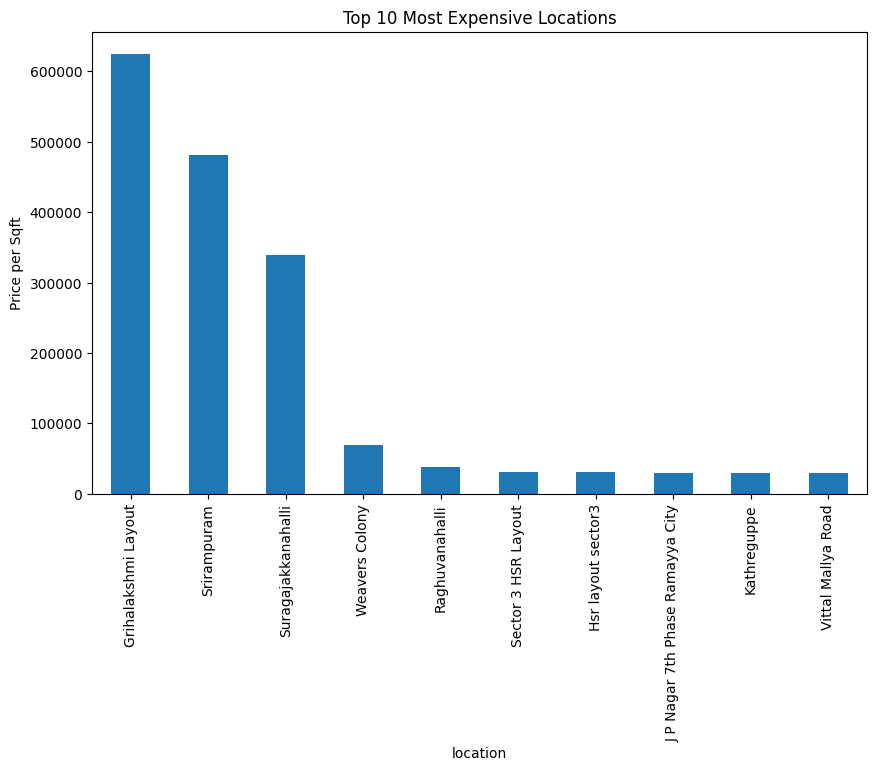

In [ ]:
plt.figure(figsize=(10,6))

location_price.head(10).plot(kind='bar')

plt.title("Top 10 Most Expensive Locations")
plt.ylabel("Price per Sqft")

plt.show()

#10. Outlier Detection

Remove unrealistic area per bedroom.

In [ ]:
df = df[~(df['total_sqft']/df['bhk'] < 300)]

Remove price per sqft outliers.

In [ ]:
def remove_pps_outliers(df):

    df_out = pd.DataFrame()

    for location, subdf in df.groupby('location'):

        mean = np.mean(subdf.price_per_sqft)
        std = np.std(subdf.price_per_sqft)

        reduced_df = subdf[(subdf.price_per_sqft > (mean - std)) &
                           (subdf.price_per_sqft < (mean + std))]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out

df = remove_pps_outliers(df)

Remove unrealistic bathroom counts.

In [ ]:
df = df[df['bath']<df['bhk']+2]

#11. Final Dataset

Drop temporary column.

In [ ]:
df = df.drop(['price_per_sqft'], axis=1)

df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Devarabeesana Halli,1672.0,3.0,2.0,150.0,3
1,Built-up Area,Devarabeesana Halli,1750.0,3.0,3.0,149.0,3
2,Super built-up Area,Devarabeesana Halli,1750.0,3.0,2.0,150.0,3
3,Super built-up Area,Devarachikkanahalli,1250.0,2.0,3.0,44.0,3
4,Super built-up Area,Devarachikkanahalli,1250.0,2.0,2.0,40.0,2


#12. Train Test Split

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#13. Preprocessing Pipeline

Categorical features

In [ ]:
categorical_features = ['area_type','location']

Pipeline

In [ ]:
preprocessor = ColumnTransformer(

    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],

    remainder='passthrough'
)

#14. Linear Regression Model

In [ ]:
lr_pipeline = Pipeline([

    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

Train model

In [ ]:
lr_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['area_type', 'location'])])),
                ('model', LinearRegression())])

Prediction

In [ ]:
lr_pred = lr_pipeline.predict(X_test)

Evaluation

In [ ]:
print("Linear Regression Performance")

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Performance
MAE: 15.960624537378044
RMSE: 30.004428303260653
R2 Score: 0.8327969694205487


#15. Random Forest Model

In [ ]:
rf_pipeline = Pipeline([

    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

Train model

In [ ]:
rf_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['area_type', 'location'])])),
                ('model', RandomForestRegressor(random_state=42))])

Prediction

In [ ]:
rf_pred = rf_pipeline.predict(X_test)

Evaluation

In [ ]:
print("Random Forest Performance")

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Performance
MAE: 14.514200369032888
RMSE: 30.773956119453597
R2 Score: 0.8241104277574424


#16. Model Comparison

In [ ]:
results = pd.DataFrame({

    "Model": ["Linear Regression","Random Forest"],

    "MAE":[
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],

    "R2":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,15.960625,30.004428,0.832797
1,Random Forest,14.514200,30.773956,0.824110


##Actual vs Predicted Visualization

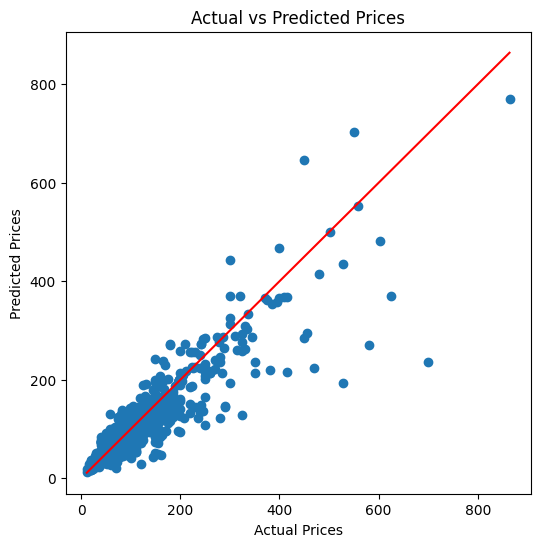

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

##Conclusion
The models were evaluated using standard regression metrics including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

The Linear Regression model achieved an R² score of 0.83, indicating that it explains approximately 83% of the variance in property prices. It also achieved an MAE of 15.96 and RMSE of 30.00, suggesting relatively accurate predictions across the dataset.

The Random Forest model achieved a comparable performance with an R² score of 0.82, MAE of 14.51, and RMSE of 30.77.

Overall, the results demonstrate that the selected features such as location, total square footage, number of bedrooms, and bathrooms are strong predictors of housing prices.